In [1]:
import torch 										# pyright: ignore[reportMissingImports]
import torchvision 									# pyright: ignore[reportMissingImports]
from torchvision import datasets, transforms 		# pyright: ignore[reportMissingImports]
from torch.utils.data import DataLoader 			# pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt 					# pyright: ignore[reportMissingModuleSource, reportMissingImports]

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device) 

Using: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),                
    transforms.Normalize((0.5,), (0.5,)), 
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 448kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.81MB/s]


In [3]:
T = 300
betas = torch.linspace(1e-4, 0.02, T)       	
alphas = 1.0 - betas                          
alpha_bars = torch.cumprod(alphas, dim=0)     	

print(betas.shape)      
print(betas[0], betas[-1])     
print(alpha_bars[0])     
print(alpha_bars[-1])    

torch.Size([300])
tensor(1.0000e-04) tensor(0.0200)
tensor(0.9999)
tensor(0.0481)


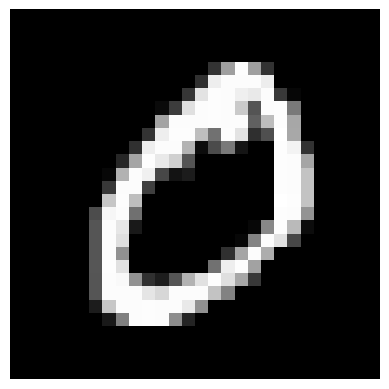

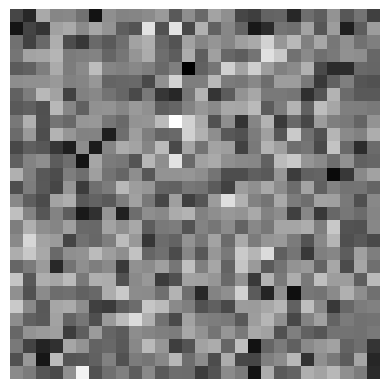

In [7]:
def q_sample(x0, t):
	e = torch.randn_like(x0)	
	return (alpha_bars[t] ** 0.5) * x0 + ((1 - alpha_bars[t]) ** 0.5) * e


def show(img_tensor):
    img = (img_tensor + 1) / 2         
    plt.imshow(img.squeeze(), cmap="gray")
    plt.axis("off")
    plt.show()

img, label = train_data[1]
x0 = img

show(x0)
show(q_sample(x0, 299))